### Project Title: Cardiovascular Disease Prediction
### Model Used: RandomForestClassifier
### Author: Ometoro Emmanuel
### Date: July 14 2026

In [1]:
# Loading dependencies 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
# Loading Machine Learning Modules 

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [3]:
# Loading the csv file to Python

dataset = pd.read_csv("C:/Users/User/Documents/Machine/Cardiovascular_Disease_Dataset.csv")

Analysing the data

In [4]:
# Checking number of rows and columns 

dataset.shape

(1000, 14)

In [5]:
# First 5 observation

dataset.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [6]:
# Last 5 observation

dataset.tail()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
995,9949544,48,1,2,139,349,0,2,183,1,5.6,2,2,1
996,9953423,47,1,3,143,258,1,1,98,1,5.7,1,0,0
997,9965859,69,1,0,156,434,1,0,196,0,1.4,3,1,1
998,9988507,45,1,1,186,417,0,1,117,1,5.9,3,2,1
999,9990855,25,1,0,158,270,0,0,143,1,4.7,0,0,0


In [7]:
# Checking if there's any missing value cus the machine will malfunction if there's any

dataset.isna().sum()

patientid            0
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64

In [8]:
# Descriptive Analysis of the dataset

dataset.describe()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
count,1.000000e+03,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.048704e+06,49.24200,0.765000,0.980000,151.747000,311.447000,0.296000,0.748000,145.477000,0.498000,2.707700,1.540000,1.222000,0.580000
std,2.895905e+06,17.86473,0.424211,0.953157,29.965228,132.443801,0.456719,0.770123,34.190268,0.500246,1.720753,1.003697,0.977585,0.493805
min,1.033680e+05,20.00000,0.000000,0.000000,94.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.536440e+06,34.00000,1.000000,0.000000,129.000000,235.750000,0.000000,0.000000,119.750000,0.000000,1.300000,1.000000,0.000000,0.000000
50%,4.952508e+06,49.00000,1.000000,1.000000,147.000000,318.000000,0.000000,1.000000,146.000000,0.000000,2.400000,2.000000,1.000000,1.000000
75%,7.681877e+06,64.25000,1.000000,2.000000,181.000000,404.250000,1.000000,1.000000,175.000000,1.000000,4.100000,2.000000,2.000000,1.000000
max,9.990855e+06,80.00000,1.000000,3.000000,200.000000,602.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


In [9]:
# Distribution of the target variable

dataset["target"].value_counts()

target
1    580
0    420
Name: count, dtype: int64

Data Preprocessing

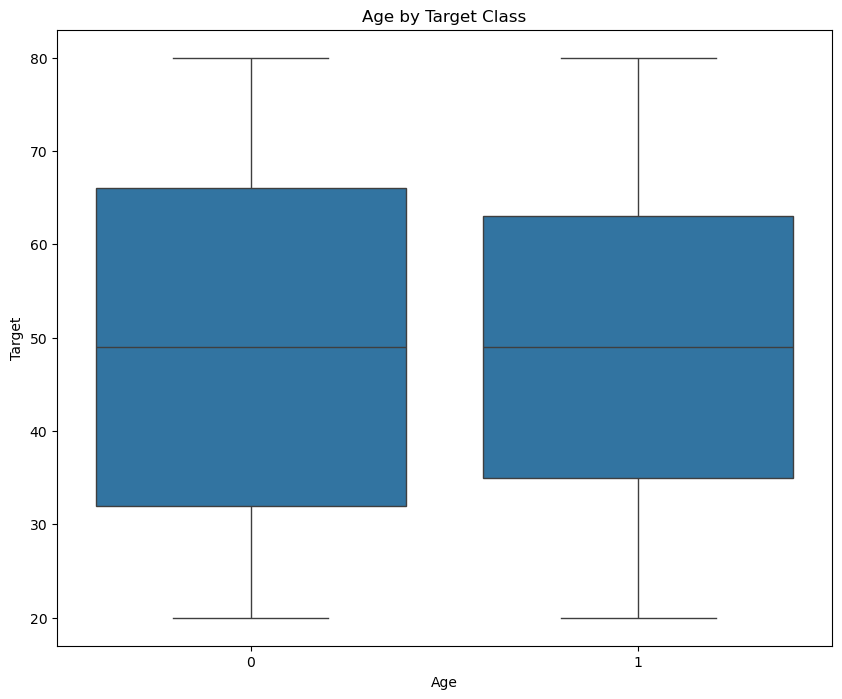

In [10]:
# Boxplot of Target vs Age

plt.figure(figsize=(10, 8))
sns.boxplot(x="target", y="age", data=dataset)
plt.title("Age by Target Class")
plt.xlabel("Age")
plt.ylabel("Target")
plt.show()



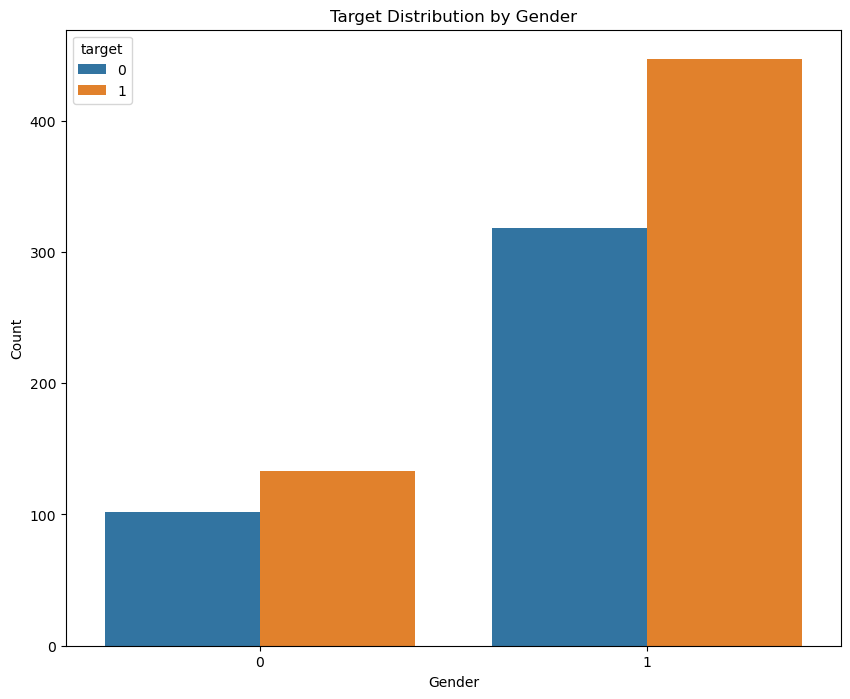

In [11]:
# Countplot of Gender vs Target

plt.figure(figsize=(10, 8))
sns.countplot(x="gender", hue="target", data=dataset)
plt.title("Target Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()



Correlation Analysis

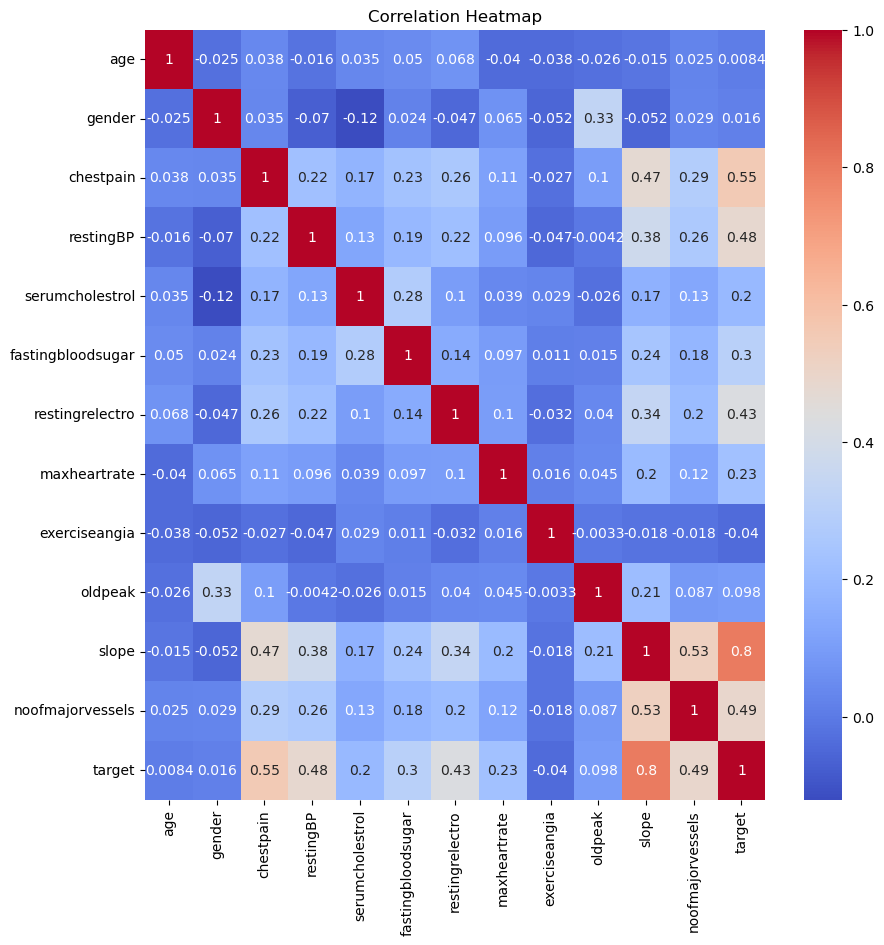

In [12]:
# Visual Correlation Analysis

correlation = dataset.drop(columns=["patientid"]).corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [13]:
# Feature Selection
# Target and Features variable

X = dataset.drop(["patientid", "target"], axis=1)
Y = dataset["target"]

In [14]:
X.head()

,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels
0,53,1,2,171,0,0,1,147,0,5.3,3,3
1,40,1,0,94,229,0,1,115,0,3.7,1,1
2,49,1,2,133,142,0,0,202,1,5.0,1,0
3,43,1,0,138,295,1,1,153,0,3.2,2,2
4,31,1,1,199,0,0,2,136,0,5.3,3,2


In [15]:
Y.head()

0    1
1    0
2    0
3    1
4    1
Name: target, dtype: int64

Cross Validation

In [16]:
# Creating a numpy array for cross validation 

X = np.array(X)
Y = np.array(Y)

In [17]:
# List of Models 
# LogisticRegression
# Support Vector Classifier
# RandomForestClassifier

models = [LogisticRegression(max_iter=1000), SVC(kernel="rbf"), RandomForestClassifier(random_state=42)]

In [18]:
# Creating a function for cross validation

def compare_models_cross_validation():

    # Processing the model one after the other 
    
    for model in models:

        cv_score = cross_val_score(model, X, Y, cv=5)
        mean_accuracy = sum(cv_score) / len(cv_score)
        mean_accuracy = round(mean_accuracy * 100, 2)
        print(f"Cross validation accuracy for {model} = {cv_score}")
        print(f"Accuracy of {model} = {mean_accuracy}")
        print("=============================================")

In [19]:
compare_models_cross_validation()

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Cross validation accuracy for LogisticRegression(max_iter=1000) = [0.955 0.995 0.93  0.975 0.96 ]
Accuracy of LogisticRegression(max_iter=1000) = 96.3
Cross validation accuracy for SVC() = [0.82 0.81 0.74 0.81 0.8 ]
Accuracy of SVC() = 79.6
Cross validation accuracy for RandomForestClassifier(random_state=42) = [0.965 1.    0.96  0.985 0.965]
Accuracy of RandomForestClassifier(random_state=42) = 97.5


#### RandomForestClassifier have the highest mean accuracy_score with 97.5%
#### LogisticRegression have the second highest mean accuracy score with 96.3%
#### Support Vector Classifier have the lowest mean aaccuracy_score with 79.6%

Traing the model

In [20]:
# Creating Variables to Train the model after RandomForestClassier Emerge as the Best

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=Y)

In [21]:
# Checking if model is diveded corretly 

X.shape, X_train.shape, X_test.shape

((1000, 12), (800, 12), (200, 12))

RandomForest Model

In [22]:
# Calling the model (RandomForestClassifier)

classifier = RandomForestClassifier()

In [23]:
# Fit the model
rf_classifier = classifier.fit(X_train, Y_train)

Model Evaluation

In [24]:
# Checking for the training data accuracy to ensure there's no underfitting and Overfitting
train_data_pred = classifier.predict(X_train)
train_data_accuracy_score = accuracy_score(Y_train, train_data_pred)
print(f"The accuracy score for train data = {train_data_accuracy_score}")

The accuracy score for train data = 1.0


In [25]:
# Checking for the testing data accuracy to ensure there's no underfitting and Overfitting
test_data_pred = classifier.predict(X_test)
test_data_accuracy_score = accuracy_score(Y_test, test_data_pred)
print(f"The accuracy score for test data = {round(test_data_accuracy_score, 2)}")

The accuracy score for test data = 0.98


#### The test data accuracy is the most important but not enough to check if the model is working perfectly

In [26]:
# Confusion Matrix (Predicted Vs Actual)
cm = confusion_matrix(Y_test, test_data_pred)
print(cm)

[[ 82   2]
 [  1 115]]


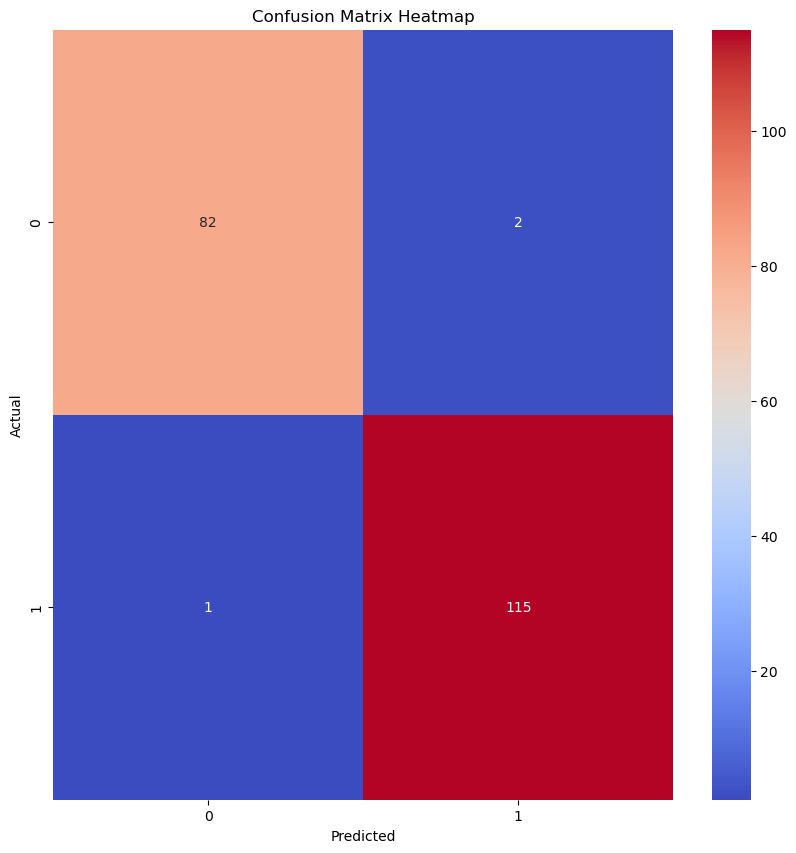

In [27]:
# Visualization of confusion matrix

plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Sub model evaluation

In [28]:
recall_score = recall_score(Y_test, test_data_pred)
print(f" Recall score = {round(recall_score, 2)}")

 Recall score = 0.99


In [29]:
f1_score = f1_score(Y_test, test_data_pred)
print(f" f1 score = {round(f1_score, 2)}")

 f1 score = 0.99


In [30]:
class_report = classification_report(Y_test, test_data_pred)
print(f" classification_report = {class_report}")

 classification_report =               precision    recall  f1-score   support

           0       0.99      0.98      0.98        84
           1       0.98      0.99      0.99       116

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



Making prediction for new data 

In [31]:
input_data = [40,1,0,94,229,0,1,115,0,3.7,1,1]
input_data_numpy = np.array(input_data)
input_data_reshape = input_data_numpy.reshape(1, -1)

prediction = classifier.predict(input_data_reshape)
print(prediction)

if prediction[0] == 0:
    print("This individual does not have Cardiovascular Disease")

else:
    print("This individual has Cardiovascular Disease")

[0]
This individual does not have Cardiovascular Disease


Importing the model to save the model

In [32]:
import pickle

Saving the trained model

In [33]:
filename = "trained_model.sav"
pickle.dump(classifier, open(filename, "wb"))

Loading the trained model

In [34]:
 loaded_model = pickle.load(open("trained_model.sav", "rb"))

Making prediction with the loaded_model variable 

In [35]:
input_data = [40,1,0,94,229,0,1,115,0,3.7,1,1]
input_data_numpy = np.array(input_data)
input_data_reshape = input_data_numpy.reshape(1, -1)

prediction = loaded_model.predict(input_data_reshape)
print(prediction)

if prediction[0] == 0:
    print("This individual does not have Cardiovascular Disease")

else:
    print("This individual has Cardiovascular Disease")

[0]
This individual does not have Cardiovascular Disease
